# 01 — The `Leaf`, in pictures

Hands-on companion to [`docs/01-leaf.md`](../docs/01-leaf.md).

> Run this with the notebook extra installed: `pip install -e ".[notebooks]"`

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

from bonsaigrad import Leaf

## A drawing helper

This walks a graph through its own `_prev` / `_op` fields — the same structure
`wire` uses — and lays nodes out by depth: roots at the bottom, the output at
the top. Each box shows the op, its `data`, and its `grad`; a node turns green
once a gradient has reached it.

With `edge_labels=True` each arrow is annotated with its **local derivative**
(`∂child/∂parent`): `1` for a `+` edge, the *other* operand for a `*` edge.
Multiply the gradient in a node by an outgoing edge label and you get the
contribution that flows to the parent — the chain rule, drawn.

In [2]:
INK, MUTED = "#2f3437", "#9aa0a6"
LIVE, LIVE_FILL = "#c1543c", "#fdece7"
INPUT_FILL, OP_FILL, IDLE_EC = "#ffffff", "#f4f5f6", "#c9ccd1"
SYM = {"+": "+", "*": "×"}


def _trace(root):
    nodes, edges, seen = [], [], set()

    def walk(n):
        if id(n) in seen:
            return
        seen.add(id(n))
        nodes.append(n)
        for p in n._prev:
            edges.append((p, n))
            walk(p)

    walk(root)
    return nodes, edges


def _depth(node, memo):
    if id(node) in memo:
        return memo[id(node)]
    d = 0 if not node._prev else 1 + max(_depth(p, memo) for p in node._prev)
    memo[id(node)] = d
    return d


def _local_deriv(child, parent):
    if child._op == "+":
        return 1.0
    if child._op == "*":
        other = child._prev[0] if child._prev[1] is parent else child._prev[1]
        return other.data.item()
    return None


def _layout(nodes, edges):
    """Place nodes by depth, then reduce edge crossings by barycentre ordering."""
    memo, levels = {}, {}
    for n in nodes:
        levels.setdefault(_depth(n, memo), []).append(n)

    xs, kids = {}, {}
    for p, ch in edges:
        kids.setdefault(id(p), []).append(ch)
    for d, layer in levels.items():
        for i, n in enumerate(layer):
            xs[id(n)] = i - (len(layer) - 1) / 2

    for _ in range(4):
        for d in sorted(levels):
            if d == max(levels):
                continue
            layer = levels[d]
            layer.sort(key=lambda n: (
                sum(xs[id(c)] for c in kids.get(id(n), [])) / len(kids[id(n)])
                if kids.get(id(n)) else xs[id(n)]))
            for i, n in enumerate(layer):
                xs[id(n)] = i - (len(layer) - 1) / 2

    return {id(n): (xs[id(n)], d) for d in levels for n in levels[d]}, max(levels), kids


def draw_graph(root, names=None, ax=None, title=None, edge_labels=False, fired=None):
    """Draw the graph above ``root``, arrows following the gradient downhill.

    ``fired`` is the set of ``id(node)`` whose ``_backward`` has already run;
    it drives what is drawn as live. Defaults to every node once ``root`` is
    seeded, i.e. the state after a full ``wire()``.
    """
    names = names or {}
    nodes, edges = _trace(root)
    pos, top, kids = _layout(nodes, edges)

    if fired is None:
        fired = {id(n) for n in nodes if n._prev} if root.grad.item() else set()
    reached = {id(n) for n in nodes if any(id(c) in fired for c in kids.get(id(n), []))}
    if root.grad.item():
        reached.add(id(root))

    if ax is None:
        _, ax = plt.subplots(figsize=(4.4, 1.5 + 1.4 * top))

    for p, ch in edges:
        (x0, y0), (x1, y1) = pos[id(p)], pos[id(ch)]
        live = id(ch) in fired
        ax.add_patch(FancyArrowPatch(
            (x1, y1), (x0, y0), arrowstyle="-|>", mutation_scale=11,
            color=LIVE if live else MUTED, lw=1.7 if live else 1.1,
            shrinkA=30, shrinkB=30, zorder=1))
        if edge_labels and (loc := _local_deriv(ch, p)) is not None:
            dx, dy = x0 - x1, y0 - y1
            norm = (dx * dx + dy * dy) ** 0.5 or 1
            ax.text((x0 + x1) / 2 - dy / norm * 0.13, (y0 + y1) / 2 + dx / norm * 0.13,
                    f"×{loc:.4g}", fontsize=8.5, zorder=3,
                    color=LIVE if live else MUTED, ha="center", va="center",
                    bbox=dict(boxstyle="round,pad=0.16", fc="white", ec="none"))

    for n in nodes:
        x, y = pos[id(n)]
        live, named = id(n) in reached, names.get(id(n))
        head = named or SYM.get(n._op, n._op) if n._prev else named or "leaf"
        if named and n._prev:
            head = f"{named} = {SYM.get(n._op, n._op)}"
        gline = f"grad  {n.grad.item():.4g}"
        parts = kids.get(id(n), [])
        if live and len(parts) > 1:
            terms = [c.grad.item() * _local_deriv(c, n) for c in parts]
            if abs(sum(terms) - n.grad.item()) < 1e-9:  # only once every path has landed
                gline += "   ({})".format(" + ".join(f"{t:.4g}" for t in terms))
        ax.text(x, y, f"$\\bf{{{head}}}$\ndata  {n.data.item():.4g}\n{gline}",
                ha="center", va="center", fontsize=8.5, color=INK, linespacing=1.5, zorder=2,
                bbox=dict(boxstyle="round,pad=0.42", lw=1.7 if live else 1.1,
                          fc=LIVE_FILL if live else (OP_FILL if n._prev else INPUT_FILL),
                          ec=LIVE if live else IDLE_EC))

    xs = [p[0] for p in pos.values()]
    ax.set_xlim(min(xs) - 0.85, max(xs) + 0.85)
    ax.set_ylim(-0.5, top + 0.5)
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=10.5, color=INK, pad=8)
    return ax

## An expression grows a graph

Writing `f = a * b + a` does not just compute a number — every `*` and `+` creates a new `Leaf` that remembers its parents. Build it one operation at a time and watch the tree grow:

```
g = a * b        # step 1
f = g + a        # step 2
```

Notice `a` is used **twice** — once inside the product, once on its own. It shows up as a single node with two arrows leaving it.

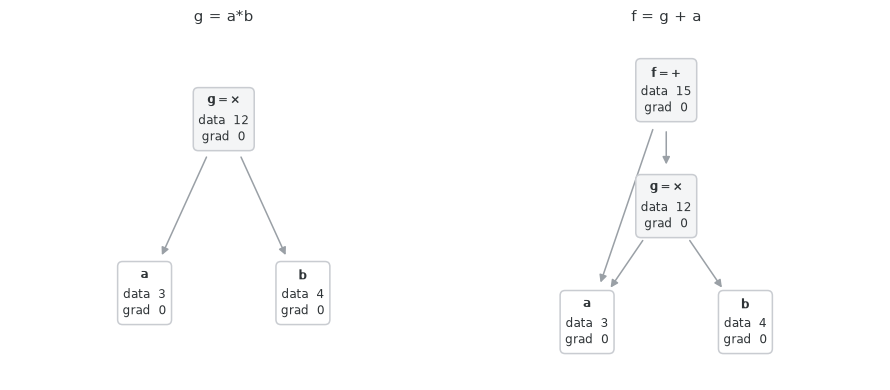

In [3]:
a = Leaf(3.0)
b = Leaf(4.0)

g = a * b
f = g + a

names = {id(a): "a", id(b): "b", id(g): "g", id(f): "f"}

steps = [(g, "g = a*b"), (f, "f = g + a")]
fig, axes = plt.subplots(1, len(steps), figsize=(9, 4.0))
for ax, (root, label) in zip(axes, steps):
    draw_graph(root, names, ax=ax, title=label)
plt.tight_layout()
plt.show()

## The backward pass, one level at a time

`wire` seeds the top with `1` and walks the tree in reverse. Here we freeze it after each level to watch the gradient cascade — a box turns green once its gradient is known.

Keep your eye on `a`. It receives gradient **twice**: first straight from `f` (step 1, `a.grad = 1`), then again through the product `g` (step 2, `+= b = 4`). The two paths add up to `a.grad = 5` — that is the `+=` in the backward rules, made visible.

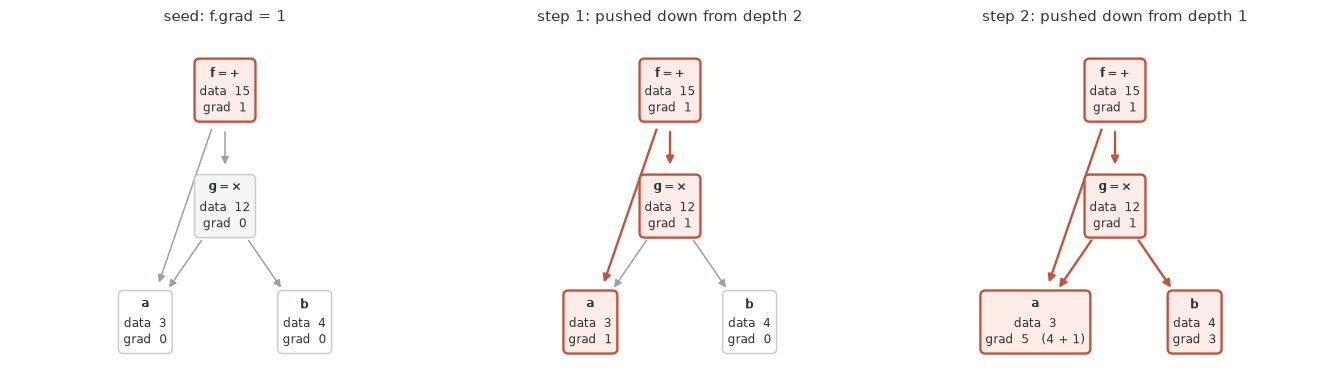

a.grad = 5.0 (expected 5.0)
b.grad = 3.0 (expected 3.0)


In [4]:
import numpy as np

nodes, _ = _trace(f)
memo, levels = {}, {}
for n in nodes:
    levels.setdefault(_depth(n, memo), []).append(n)

for n in nodes:  # clean slate
    n.grad = np.zeros_like(n.data)
f.grad = np.ones_like(f.data)  # seed the output

depths = sorted(levels, reverse=True)
fired = set()  # nodes whose _backward has run

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0))
draw_graph(f, names, ax=axes[0], title="seed: f.grad = 1", fired=set())
for k, depth in enumerate(depths[:-1], start=1):  # leaves have no parents
    for node in levels[depth]:
        node._backward()
        fired.add(id(node))
    draw_graph(f, names, ax=axes[k], title=f"step {k}: pushed down from depth {depth}",
               fired=set(fired))
plt.tight_layout()
plt.show()

print("a.grad =", a.grad.item(), "(expected 5.0)")
print("b.grad =", b.grad.item(), "(expected 3.0)")
assert a.grad.item() == 5.0 and b.grad.item() == 3.0

## A tiny neuron

The same machinery already gives us a single neuron: `y = w * x + b`. Weight `w`,
input `x`, bias `b`. Below, the graph before and after `wire`, side by side.

By hand, `∂y/∂w = x`, `∂y/∂x = w`, `∂y/∂b = 1` — read them straight off the green
boxes on the right.

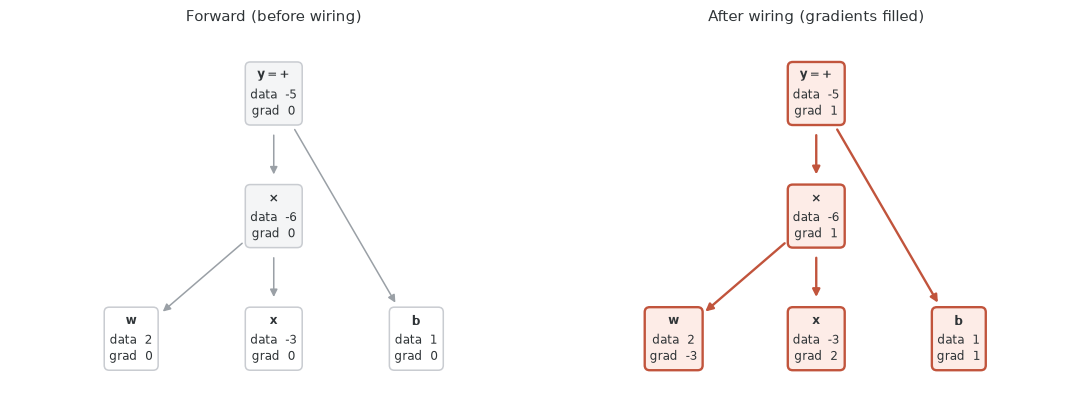

y = -5.0  |  w.grad = -3.0  x.grad = 2.0  b.grad = 1.0


In [5]:
w, x, b = Leaf(2.0), Leaf(-3.0), Leaf(1.0)
y = w * x + b
names = {id(w): "w", id(x): "x", id(b): "b", id(y): "y"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
draw_graph(y, names, ax=ax1, title="Forward (before wiring)")
y.wire()
draw_graph(y, names, ax=ax2, title="After wiring (gradients filled)")
plt.tight_layout()
plt.show()

print(f"y = {y.data.item()}  |  w.grad = {w.grad.item()}  x.grad = {x.grad.item()}  b.grad = {b.grad.item()}")

## The example

`L = (a + b) * (b + c)` — two sums feeding one product. `b` is used **twice**, so it shows up as a single node with two arrows leaving it, one into each sum.

Below, the graph after the forward pass and again after `wire`. Each edge is labelled (in red) with its **local derivative** `∂child/∂parent`: `1` for a `+` edge, the *other* operand for a `*` edge. A node's gradient times an outgoing edge label is what flows to the parent — the chain rule, drawn. Because `b` feeds both sums, it collects gradient from both paths: `7 + 5 = 12`.

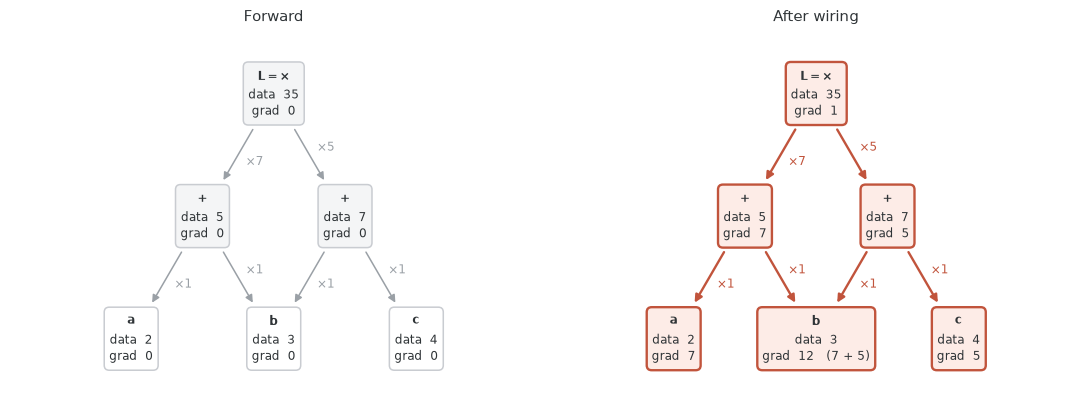

L = 35.0
a.grad = 7
b.grad = 12
c.grad = 5


In [6]:
a, b, c = Leaf(2.0), Leaf(3.0), Leaf(4.0)
L = (a + b) * (b + c)

names = {id(a): "a", id(b): "b", id(c): "c", id(L): "L"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
draw_graph(L, names, ax=ax1, title="Forward", edge_labels=True)
L.wire()
draw_graph(L, names, ax=ax2, title="After wiring", edge_labels=True)
plt.tight_layout()
plt.show()

print("L =", L.data.item())
for name, leaf in zip("abc", (a, b, c)):
    print(f"{name}.grad = {leaf.grad.item():.0f}")